# Notebook 07 — Construct Distinctiveness of the Moderators

**Dissertation:** *Beyond Money: Who Responds to Intergenerational Appeals for Sustainable Cooperation?*

The three moderators tested in Notebooks 03–04 — political ideology (`liberal_z`), environmental concern (`env_concern_z`), and legacy concern (`legacy_z`) — could conceivably index a single underlying disposition (a broad "green identity") rather than three separable constructs. If they did, their separate treatment in the moderation analysis would be redundant and their individual interpretation unsafe.

This notebook assesses that possibility through five complementary checks:

1. **Inter-construct correlations** at the participant level — the simplest test of overlap, and a prerequisite for interpreting the augmented model in Section 7 (it establishes whether ideology and environmental concern are collinear enough to destabilise a joint model).
2. **Internal-consistency reliability** of the two multi-item composites — reported for completeness; this measures cohesion *within* each scale and is not itself a test of cross-construct distinctiveness.
3. **Item-level exploratory factor analysis** of the 36 environmental and legacy items — the direct test of whether these items resolve into distinct dimensions or collapse onto one.
4. **Convergent validity of legacy concern against parenthood** — establishing that legacy concern, having been shown to be *distinct* from the environmental measures, nonetheless tracks an independent behavioural criterion in the manner generativity theory predicts.
5. **Augmented H1 model** — whether the ideology term retains explanatory value once environmental concern is included, addressing the practical question of whether ideology contributes independently of environmental disposition.

Sections 3–5 and 7 are restricted to the Prolific study, the only study in which legacy concern and environmental concern were collected. Section 6 draws on both studies where the data permit: the number of children was recorded in each, so the confounder checks span MTurk and Prolific, while the legacy-concern validity analysis is necessarily Prolific-only. The `liberal_z` measure is a single ideology item; it therefore enters the correlation and augmented-model analyses but not the item-level factor analysis, which requires multi-item scales.


## 1 · Setup

In [1]:
# Cell 1: Imports and configuration
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.regression.mixed_linear_model import MixedLM
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 60)
plt.rcParams.update({'figure.dpi': 150})

os.makedirs('outputs/tables', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)

TREAT_MAP = {1: 'IT&GI', 2: 'IT', 3: 'GI', 4: 'NIT&NGI'}

# The 36 composite items. Reverse-scored items were already reversed in
# Notebook 01 (in place, before composite construction) and written to the
# clean file, so every item below is oriented consistently: higher = more of
# the construct. No further recoding is applied here.
ENV_ITEMS = [f'environment_{s}{i}'
             for s in ['mov', 'threat', 'beha', 'uti', 'growth']
             for i in range(1, 7)]
LEGACY_ITEMS = [f'legacy_concern{i}' for i in range(1, 7)]
ALL_ITEMS = ENV_ITEMS + LEGACY_ITEMS

print('Environment ready.')

Environment ready.


## 2 · Data

The Prolific analytic file is loaded and collapsed to participant level (one row per participant); all moderator and item variables are time-invariant within participant, so the first observation is a lossless summary. Factor-analytic and correlation computations operate at this level.

In [2]:
# Cell 2: Load Prolific analytic data and reduce to participant level
pr = pd.read_csv('data/prolific_clean.csv')
pr['treatment_str'] = pr['treatment'].map(TREAT_MAP)
pr['round_c'] = pr['round'] - pr['round'].mean()

participant = pr.groupby('participantcode').first()

moderators = ['liberal_z', 'env_concern_z', 'legacy_z']
n_complete_mod = participant[moderators].dropna().shape[0]
n_complete_items = participant[ALL_ITEMS].dropna().shape[0]

print(f'Prolific participants: {len(participant):,}')
print(f'Complete on all three moderators: {n_complete_mod:,}')
print(f'Complete on all 36 composite items: {n_complete_items:,}')

Prolific participants: 1,017
Complete on all three moderators: 1,017
Complete on all 36 composite items: 1,017


## 3 · Inter-Construct Correlations

Pearson correlations among the three moderators at the participant level. Moderate correlations are expected between ideology and environmental concern; a substantially lower association for legacy concern would be consistent with it indexing a distinct, non-environmental disposition. Correlations approaching or exceeding 0.7 between any pair would raise a multicollinearity concern for the joint model in Section 5.

In [3]:
# Cell 3: Participant-level correlation matrix among the three moderators
corr = participant[moderators].corr()
corr.to_csv('outputs/tables/moderator_correlations.csv')
print('Pearson correlations (participant level, Prolific):')
print(corr.to_string())

# Flag any pair at or above the collinearity threshold used to judge the
# joint model in Section 5.
COLLIN_THRESHOLD = 0.70
flagged = [(a, b, corr.loc[a, b]) for i, a in enumerate(moderators)
           for b in moderators[i + 1:] if abs(corr.loc[a, b]) >= COLLIN_THRESHOLD]
print()
if flagged:
    for a, b, r in flagged:
        print(f'  NOTE: |r({a}, {b})| = {abs(r):.3f} >= {COLLIN_THRESHOLD} — joint model interpreted with caution')
else:
    print(f'No moderator pair reaches |r| = {COLLIN_THRESHOLD}; joint estimation in Section 5 is not collinearity-threatened.')

Pearson correlations (participant level, Prolific):
               liberal_z  env_concern_z  legacy_z
liberal_z          1.000         -0.558     0.126
env_concern_z     -0.558          1.000    -0.025
legacy_z           0.126         -0.025     1.000

No moderator pair reaches |r| = 0.7; joint estimation in Section 5 is not collinearity-threatened.


## 4 · Internal-Consistency Reliability

Cronbach's α for the two multi-item composites, recomputed here at participant level for a self-contained record. Reliability quantifies cohesion *within* a scale; it does not test whether two scales measure the same thing, and it is reported here only to document that each composite is internally coherent before its items enter the factor analysis. The single-item ideology measure has no internal-consistency coefficient.

In [4]:
# Cell 4: Cronbach's alpha for the two composites
def cronbach_alpha(item_frame):
    item_frame = item_frame.dropna()
    k = item_frame.shape[1]
    item_var = item_frame.var(axis=0, ddof=1).sum()
    total_var = item_frame.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var / total_var)

alpha_env = cronbach_alpha(participant[ENV_ITEMS])
alpha_leg = cronbach_alpha(participant[LEGACY_ITEMS])
print(f'Environmental concern (30 items): alpha = {alpha_env:.3f}')
print(f'Legacy concern (6 items):         alpha = {alpha_leg:.3f}')

pd.DataFrame({
    'scale': ['Environmental concern', 'Legacy concern'],
    'n_items': [len(ENV_ITEMS), len(LEGACY_ITEMS)],
    'cronbach_alpha': [round(alpha_env, 3), round(alpha_leg, 3)],
}).to_csv('outputs/tables/composite_reliability.csv', index=False)

Environmental concern (30 items): alpha = 0.927
Legacy concern (6 items):         alpha = 0.856


## 5 · Item-Level Exploratory Factor Analysis

The 36 environmental and legacy items are factor-analysed jointly to test whether they resolve into distinct dimensions or collapse onto a single "green identity" factor. Ideology is a single item and is excluded from the item-level model.

The procedure is: (i) verify factorability with the Kaiser–Meyer–Olkin measure and Bartlett's test of sphericity; (ii) determine the number of factors to retain via the Kaiser criterion and a scree plot; (iii) fit a solution with oblique (promax) rotation, which allows correlated factors — appropriate because environmental and legacy dispositions are expected to co-vary rather than be orthogonal. The question of interest is whether the legacy items form a factor separable from the environmental items.

In [5]:
# Cell 5a: Factorability diagnostics
fa_data = participant[ALL_ITEMS].dropna()
print(f'Factor-analytic sample: {fa_data.shape[0]:,} participants x {fa_data.shape[1]} items')

chi_sq, bart_p = calculate_bartlett_sphericity(fa_data)
kmo_per_item, kmo_total = calculate_kmo(fa_data)
print(f"Bartlett's test of sphericity: chi2 = {chi_sq:,.0f}, p = {bart_p:.2e}")
print(f'Kaiser-Meyer-Olkin (overall):  {kmo_total:.3f}')
print()
if kmo_total >= 0.8 and bart_p < 0.05:
    print('Data are highly suitable for factor analysis (KMO >= 0.80, Bartlett p < 0.05).')
elif kmo_total >= 0.6 and bart_p < 0.05:
    print('Data are acceptable for factor analysis (KMO >= 0.60, Bartlett p < 0.05).')
else:
    print('Factorability is marginal; interpret the solution with caution.')

Factor-analytic sample: 1,017 participants x 36 items
Bartlett's test of sphericity: chi2 = 22,970, p = 0.00e+00
Kaiser-Meyer-Olkin (overall):  0.920

Data are highly suitable for factor analysis (KMO >= 0.80, Bartlett p < 0.05).


Factors with eigenvalue > 1 (Kaiser): 7
First 10 eigenvalues: [10.28  4.48  3.1   2.33  1.95  1.22  1.17  0.88  0.74  0.68]


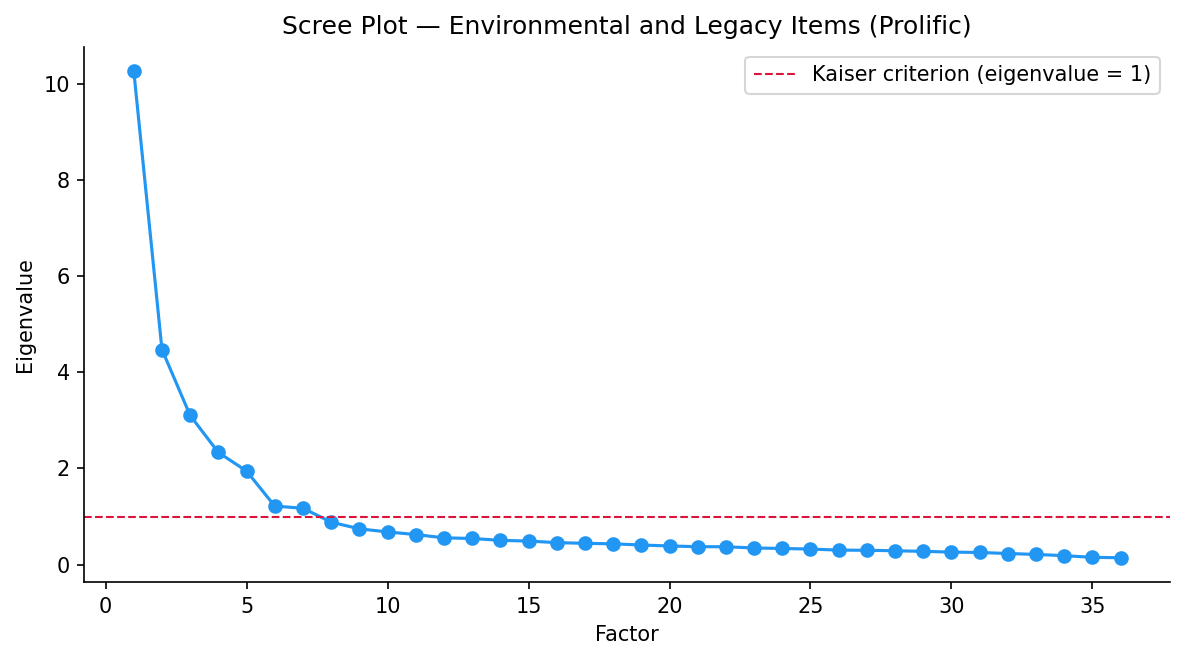

In [6]:
# Cell 5b: Number of factors -- Kaiser criterion and scree plot
fa_full = FactorAnalyzer(n_factors=len(ALL_ITEMS), rotation=None)
fa_full.fit(fa_data)
eigenvalues, _ = fa_full.get_eigenvalues()

n_kaiser = int((eigenvalues > 1).sum())
print(f'Factors with eigenvalue > 1 (Kaiser): {n_kaiser}')
print('First 10 eigenvalues:', np.round(eigenvalues[:10], 2))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'o-', color='#2196F3', linewidth=1.5)
ax.axhline(1, color='crimson', linestyle='--', linewidth=1, label='Kaiser criterion (eigenvalue = 1)')
ax.set_xlabel('Factor')
ax.set_ylabel('Eigenvalue')
ax.set_title('Scree Plot — Environmental and Legacy Items (Prolific)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/figures/efa_scree_plot.png', dpi=200, bbox_inches='tight')
plt.show()

In [7]:
# Cell 5c: Two-factor solution with oblique (promax) rotation
# A two-factor model directly tests the environmental-vs-legacy separation that
# motivates this notebook. (The Kaiser criterion above may suggest more factors,
# reflecting the five environmental sub-scales; those sub-factor distinctions are
# secondary to the environmental/legacy question examined here, and the full
# Kaiser-implied solution is available from fa_full for the interested reader.)
fa2 = FactorAnalyzer(n_factors=2, rotation='promax')
fa2.fit(fa_data)

loadings = pd.DataFrame(fa2.loadings_, index=ALL_ITEMS, columns=['Factor 1', 'Factor 2'])
loadings['scale'] = ['Environmental'] * len(ENV_ITEMS) + ['Legacy'] * len(LEGACY_ITEMS)
loadings.to_csv('outputs/tables/efa_loadings_2factor.csv')

# Mean absolute loading of each item block on each factor summarises the pattern.
summary = loadings.groupby('scale')[['Factor 1', 'Factor 2']].apply(lambda d: d.abs().mean())
print('Mean absolute loading by item block (2-factor promax):')
print(summary.round(3).to_string())
print()
print('Legacy item loadings:')
print(loadings.loc[LEGACY_ITEMS, ['Factor 1', 'Factor 2']].round(3).to_string())
print()
print('Factor correlation (promax allows correlated factors):')
print(pd.DataFrame(fa2.phi_, columns=['Factor 1', 'Factor 2'], index=['Factor 1', 'Factor 2']).round(3).to_string())

Mean absolute loading by item block (2-factor promax):
               Factor 1  Factor 2
scale                            
Environmental     0.541     0.202
Legacy            0.161     0.602

Legacy item loadings:
                 Factor 1  Factor 2
legacy_concern1    -0.151     0.676
legacy_concern2    -0.128     0.619
legacy_concern3    -0.235     0.626
legacy_concern4    -0.156     0.627
legacy_concern5    -0.073     0.456
legacy_concern6    -0.224     0.607

Factor correlation (promax allows correlated factors):
          Factor 1  Factor 2
Factor 1     1.000     0.130
Factor 2     0.130     1.000


## 6 · Parenthood: Convergent Validity and Confounder Checks

Sections 3 and 5 establish that legacy concern is *distinct* from environmental concern and ideology. Distinctiveness alone, however, does not establish that the measure captures the intended construct: a scale can be statistically separable from its neighbours and still measure little of substance. Generativity theory (McAdams & de St. Aubin), from which the legacy-concern scale derives, holds that concern for one's legacy is bound up with investment in future generations, of which raising children is the most direct expression. Parenthood therefore supplies an external criterion against which the measure can be validated.

**Study coverage.** The number of children (`prole`) was collected in *both* studies, but legacy concern was administered in Prolific only. The analysis below is therefore split accordingly:

- **Convergent validity (Prolific only)** — the association between `prole` and `legacy_z`. This cannot be computed for MTurk, where the legacy-concern scale was not administered.
- **Confounder checks (both studies)** — whether `prole` is balanced across treatment conditions and whether it predicts the outcome. These require only `prole` and the treatment assignment, so they run in both studies and establish, for the full analytic sample, that parenthood need not be adjusted for in Notebooks 03–05.
- **Parenthood and ideology (both studies)** — reported as a secondary observation, since ideology is the one moderator available in both.

The legacy-concern association is examined in three ways: a correlation across the full count, a parent versus non-parent contrast with an effect size, and — because `prole` is a heavily right-skewed count with the majority of participants at zero — a rank-based correlation as a distributional robustness check. The binary parent/non-parent contrast is the primary quantity, being least sensitive to the skew.


In [8]:
# Cell 6: Parenthood -- convergent validity (Prolific) and confounder checks (both studies)
from scipy import stats

# Both studies are needed here; Notebook 07 otherwise works with Prolific alone.
mt = pd.read_csv('data/mturk_clean.csv')
mt['treatment_str'] = mt['treatment'].map(TREAT_MAP)
participant_mt = mt.groupby('participantcode').first()

STUDIES = {
    'Study 1 (MTurk)': (mt, participant_mt),
    'Study 2 (Prolific)': (pr, participant),
}

# --- 6a. Convergent validity: prole vs legacy_z (Prolific only) --------------
# legacy_z is entirely missing in MTurk (the scale was not administered there),
# so this association is estimable in Prolific alone.
print('=' * 72)
print('6a. Convergent validity of legacy concern against parenthood (Prolific only)')
print('=' * 72)

validity = participant[['prole', 'legacy_z']].dropna().copy()
validity['is_parent'] = (validity['prole'] > 0).astype(int)

non_parents = validity.loc[validity['is_parent'] == 0, 'legacy_z']
parents = validity.loc[validity['is_parent'] == 1, 'legacy_z']
t_stat, p_t = stats.ttest_ind(parents, non_parents, equal_var=False)   # Welch
pooled_sd = np.sqrt((parents.var(ddof=1) + non_parents.var(ddof=1)) / 2)
cohens_d = (parents.mean() - non_parents.mean()) / pooled_sd
r_pearson, p_pearson = stats.pearsonr(validity['prole'], validity['legacy_z'])
r_spearman, p_spearman = stats.spearmanr(validity['prole'], validity['legacy_z'])

print(f'n = {len(validity):,}')
print(f'  Non-parents (n = {len(non_parents):,}): mean legacy_z = {non_parents.mean():+.3f}')
print(f'  Parents     (n = {len(parents):,}): mean legacy_z = {parents.mean():+.3f}')
print(f"  Welch t = {t_stat:.3f}, p = {p_t:.4g}, Cohen's d = {cohens_d:.3f}   [primary quantity]")
print(f'  Pearson  r   = {r_pearson:.3f} (p = {p_pearson:.4g})')
print(f'  Spearman rho = {r_spearman:.3f} (p = {p_spearman:.4g})   [rank-based, robust to skew]')

# --- 6b. Confounder checks: both studies ------------------------------------
print()
print('=' * 72)
print('6b. Is parenthood a confounder? Balance and outcome checks (both studies)')
print('=' * 72)

confounder_rows = []
for label, (round_df, part_df) in STUDIES.items():
    sub = part_df[['prole', 'treatment']].dropna()
    f_stat, p_balance = stats.f_oneway(*[g['prole'].values for _, g in sub.groupby('treatment')])

    green_rate = round_df.groupby('participantcode')['extract_green_choice'].mean().rename('green_rate')
    outcome = part_df[['prole']].join(green_rate).dropna()
    r_outcome, p_outcome = stats.pearsonr(outcome['prole'], outcome['green_rate'])

    r_ideol, p_ideol = stats.pearsonr(part_df['prole'], part_df['liberal_z'])
    parent_rate = (part_df['prole'] > 0).mean()

    print(f'\n{label}  (n = {len(part_df):,}; {parent_rate:.1%} are parents)')
    print(f'  Balance across treatment (ANOVA): F = {f_stat:.3f}, p = {p_balance:.4g}')
    print(f'  Association with green-choice rate: r = {r_outcome:.3f}, p = {p_outcome:.4g}')
    print(f'  Association with ideology:          r = {r_ideol:.3f}, p = {p_ideol:.4g}')
    if p_balance > 0.05 and p_outcome > 0.05:
        print('  -> Balanced across conditions and unrelated to the outcome: not a confounder.')

    confounder_rows.append({
        'study': label, 'n': len(part_df), 'parent_rate': round(parent_rate, 4),
        'balance_F': round(f_stat, 4), 'balance_p': round(p_balance, 4),
        'r_outcome': round(r_outcome, 4), 'p_outcome': round(p_outcome, 4),
        'r_ideology': round(r_ideol, 4), 'p_ideology': round(p_ideol, 4),
    })

print()
print('Parenthood is balanced across treatment and unrelated to green choice in both')
print('studies; it is therefore not adjusted for in the models of Notebooks 03-05.')

# --- Export -----------------------------------------------------------------
pd.DataFrame({
    'quantity': ['Pearson r (prole, legacy_z)', 'Spearman rho (prole, legacy_z)',
                 'Mean legacy_z, non-parents', 'Mean legacy_z, parents',
                 "Cohen's d (parents - non-parents)", 'Welch t', 'Welch p'],
    'value': [r_pearson, r_spearman, non_parents.mean(), parents.mean(),
              cohens_d, t_stat, p_t],
    'study': ['Study 2 (Prolific)'] * 7,
}).round(4).to_csv('outputs/tables/legacy_parenthood_validity.csv', index=False)

pd.DataFrame(confounder_rows).to_csv('outputs/tables/parenthood_confounder_checks.csv', index=False)

6a. Convergent validity of legacy concern against parenthood (Prolific only)
n = 1,017
  Non-parents (n = 625): mean legacy_z = -0.168
  Parents     (n = 392): mean legacy_z = +0.269
  Welch t = 7.073, p = 3.09e-12, Cohen's d = 0.451   [primary quantity]
  Pearson  r   = 0.212 (p = 8.756e-12)
  Spearman rho = 0.216 (p = 3.652e-12)   [rank-based, robust to skew]

6b. Is parenthood a confounder? Balance and outcome checks (both studies)

Study 1 (MTurk)  (n = 1,022; 54.7% are parents)
  Balance across treatment (ANOVA): F = 0.550, p = 0.6485
  Association with green-choice rate: r = 0.045, p = 0.1469
  Association with ideology:          r = 0.144, p = 4.109e-06
  -> Balanced across conditions and unrelated to the outcome: not a confounder.

Study 2 (Prolific)  (n = 1,017; 38.5% are parents)
  Balance across treatment (ANOVA): F = 0.619, p = 0.603
  Association with green-choice rate: r = 0.011, p = 0.7205
  Association with ideology:          r = 0.245, p = 2.004e-15
  -> Balanced acros

## 7 · Ideology Net of Environmental Concern

The practical question behind the "single construct" concern is whether ideology contributes anything beyond environmental disposition. The H1 main-effect model is re-estimated with `env_concern_z` added as a covariate; if the `liberal_z` coefficient is materially unchanged, ideology carries information independent of environmental concern. The model retains the three-level structure used throughout (rounds nested in participants nested in sessions). This test is interpreted in light of the Section 3 correlation: if ideology and environmental concern are not strongly collinear, their coefficients in the joint model are separately identifiable.

Because H1 examines an ideology main effect rather than a moderation effect, `liberal_z` and `env_concern_z` enter as main effects here; treatment is retained as a control, consistent with the H1 specification in Notebook 03.


In [9]:
# Cell 7: Augmented H1 model -- ideology adjusted for environmental concern
def fit_lpm(df, formula):
    import patsy
    _, design = patsy.dmatrices(formula, df, return_type='dataframe', NA_action='drop')
    fit_df = df.loc[design.index].dropna(subset=['sessioncode', 'participantcode'])
    model = MixedLM.from_formula(formula, groups='sessioncode', re_formula='1',
                                 vc_formula={'participant': '0 + C(participantcode)'}, data=fit_df)
    result = model.fit(reml=True, method=['lbfgs', 'bfgs', 'cg', 'powell', 'nm'], maxiter=2000, disp=False)
    if not result.converged:
        print('WARNING: model did not converge with any optimizer in the retry sequence.')
    return result

H1_BASE = 'extract_green_choice ~ liberal_z + C(treatment, Treatment(reference=4)) + round_c'
H1_AUGMENTED = 'extract_green_choice ~ liberal_z + env_concern_z + C(treatment, Treatment(reference=4)) + round_c'

res_base = fit_lpm(pr, H1_BASE)
res_aug = fit_lpm(pr, H1_AUGMENTED)

comparison = pd.DataFrame({
    'H1 base (Prolific)': [res_base.params['liberal_z'], res_base.bse['liberal_z'], res_base.pvalues['liberal_z']],
    'H1 + env_concern_z': [res_aug.params['liberal_z'], res_aug.bse['liberal_z'], res_aug.pvalues['liberal_z']],
}, index=['liberal_z coef', 'liberal_z se', 'liberal_z p'])
comparison.to_csv('outputs/tables/ideology_net_of_env_concern.csv')

print('liberal_z coefficient, before and after adjusting for env_concern_z:')
print(comparison.round(4).to_string())
print()
print('env_concern_z in the augmented model: '
      f"coef = {res_aug.params['env_concern_z']:.4f}, p = {res_aug.pvalues['env_concern_z']:.4f}")

liberal_z coefficient, before and after adjusting for env_concern_z:
                H1 base (Prolific)  H1 + env_concern_z
liberal_z coef              -0.013              -0.010
liberal_z se                 0.008               0.009
liberal_z p                  0.091               0.265

env_concern_z in the augmented model: coef = 0.0050, p = 0.5781


## 8 · Summary

The five checks jointly characterise the moderators' measurement properties. The correlation matrix (Section 3) quantifies pairwise overlap; the reliability coefficients (Section 4) confirm each composite is internally coherent; the factor analysis (Section 5) tests whether the environmental and legacy items separate empirically; the parenthood analysis (Section 6) supplies external validation of the legacy-concern measure against a criterion implied by generativity theory, while simultaneously establishing that parenthood is not a confounder of the treatment effects; and the augmented model (Section 7) establishes whether ideology contributes independently of environmental concern.

Read together, these determine whether the separate moderator treatment in Notebooks 03–04 is warranted, or whether the constructs should instead be regarded as a single underlying disposition. The exported tables and scree plot provide the supporting evidence for the corresponding passage of the dissertation.
